# Equity Derivatives Part II — Homework Solutions

**Scenario.** At **10:00 am, March 8, 2019**, AAPL trades at $S_0 = \$171.01$. As a portfolio
manager you sell **1 unit of a European Call** on AAPL, strike $K=\$180$, maturity $T=1$ year.

**Market data (constant across Part 1–3 unless stated otherwise):**

| Symbol | Meaning (slide notation) | Value |
|---|---|---|
| $S_0$ | Spot price of AAPL | \$171.01 |
| $K$ | Strike (base option) | \$180 |
| $r$ | risk-free interest rate | 3% |
| $\mu$ | real-world drift of AAPL ($\mu$ *does not appear* in the BS formula — slide 6, "The Black-Scholes Formula") | 5% |
| $\sigma$ | volatility | 10% |
| $c$ | **dividend yield** (slide notation — see below) | 0% |
| $T$ | Maturity | 1 year |

**Lining up with the lecture slides — the dividend yield $c$.** The slides price everything off
the *general* Black-Scholes formula for a stock with a **continuous dividend yield $c$**
("*The Black-Scholes Model*" slide 2: *"The stock pays a dividend yield of $c$"*). Every formula
below is written with $c$ **exactly as in the slides**, and we carry `c` as an explicit
parameter in the code. This problem states *"no dividend"*, i.e. $c=0$, so $e^{-cT}=1$
throughout and every formula collapses to its familiar no-dividend form — but keeping $c$
symbolic makes it trivial to see exactly which slide formula each line of code is implementing.

**Also lining up with the slides — $\mu$ is a red herring for pricing.** Slide 6 of
*"The Black-Scholes Model"* states explicitly: *"Note that $\mu$ does not appear in the
Black-Scholes formula — just as $p$ is not used in option pricing calculations for the binomial
model."* Risk-neutral pricing replaces the real-world drift $\mu$ with $r-c$ (slide 5:
$S_t=S_0e^{(r-c-\sigma^2/2)t+\sigma W_t}$ under $\mathbb{Q}$). So $\mu=5\%$ is scenario context
only and will not appear in any formula below.

**Rounding convention used throughout:** every reported number is rounded to 4 decimals using
"round-half-up" (e.g. $0.00005\to 0.0001$), matching the assignment's instructions. Intermediate
values (e.g. $d_1$) are *carried at full floating-point precision* through the calculation and
only rounded for **display**, which avoids compounding rounding error.

The notebook is organized exactly as the assignment:

- **Part 1 (Q1–Q8):** BMS Greeks and Delta-Hedging → slide decks *"The Black-Scholes Model"*,
  *"The Greeks: Delta and Gamma"*, *"The Greeks: Vega and Theta"*, *"Delta-Hedging"*.
- **Part 2 (Q9–Q10):** Volatility Surface I → slide deck *"The Volatility Surface"*.
- **Part 3 (Q11–Q14):** Digital Option and Volatility Surface II → slide deck
  *"Pricing Derivatives Using the Volatility Surface"*.


In [51]:
import math
from decimal import Decimal, ROUND_HALF_UP

import numpy as np
import pandas as pd
from scipy.stats import norm

def round4(x: float) -> float:
    """Round-half-up to 4 decimals (0.00005 -> 0.0001), per assignment convention."""
    return float(Decimal(repr(float(x))).quantize(Decimal('0.0001'), rounding=ROUND_HALF_UP))

# ---- Common market data (10am, March 8, 2019) -----------------------------
# Symbols match the slides exactly: S0, K, r, sigma, T, and dividend yield c.
S0    = 171.01   # AAPL spot
K1    = 180.0    # strike of the base call (Q1-Q8, Q11-Q14 "K=180" leg)
K2    = 185.0    # strike of the second leg used in the spreads (Q9, Q10, Q13, Q14)
r     = 0.03     # risk-free interest rate
mu    = 0.05     # real-world drift (does NOT appear in the BS formula -- slide 6)
sigma = 0.10     # volatility (flat-vol world)
c     = 0.0      # dividend yield (slide notation) -- "no dividend" given in the problem
T     = 1.0      # maturity in years

print(f"S0={S0}, K1={K1}, K2={K2}, r={r}, sigma={sigma}, c={c}, T={T}")


S0=171.01, K1=180.0, K2=185.0, r=0.03, sigma=0.1, c=0.0, T=1.0


## Black–Scholes formula reference (slide: *"Review: The Black-Scholes Formula"*)

$$
C_0(S_0,\sigma,T)=S_0e^{-cT}N(d_1)-Ke^{-rT}N(d_2)
\tag{slide eq. 9}
$$

$$
d_1=\frac{\log(S_0/K)+(r-c+\sigma^2/2)\,T}{\sigma\sqrt{T}},
\qquad d_2=d_1-\sigma\sqrt{T}
$$

and $N(d)=\mathsf P(N(0,1)\le d)$, with $\varphi(\cdot)=N'(\cdot)$ the standard normal PDF.

**The Greeks** (slides *"Delta and Gamma"*, *"Vega and Theta"*), each stated exactly as on the
slide, *before* we set $c=0$:

$$
\text{Call-Delta}=\frac{\partial C}{\partial S}=e^{-cT}N(d_1)
\qquad\text{(slide: "Delta")}
$$

$$
\text{Gamma}=\frac{\partial^2 C}{\partial S^2}=e^{-cT}\frac{\varphi(d_1)}{\sigma S\sqrt{T}}
\qquad\text{(slide: "Gamma")}
$$

$$
\text{Vega}=\frac{\partial C}{\partial \sigma}=e^{-cT}S\sqrt{T}\,\varphi(d_1)
\qquad\text{(slide: "Vega")}
$$

$$
\text{Theta}=-\frac{\partial C}{\partial T}
=-e^{-cT}S\varphi(d_1)\frac{\sigma}{2\sqrt{T}}+ce^{-cT}SN(d_1)-rKe^{-rT}N(d_2)
\qquad\text{(slide: "Theta")}
$$

Since this problem has **$c=0$** (no dividend), $e^{-cT}=1$ and the $c\,e^{-cT}SN(d_1)$ term in
Theta vanishes, giving exactly the textbook no-dividend formulas we compute below. We keep `c` as
an explicit function argument (default $0$) purely so the code is a literal transcription of the
slide formulas, not a special-cased simplification of them.


In [52]:
def d1d2(S, K, sigma, tau, r=r, c=c):
    d1 = (math.log(S / K) + (r - c + 0.5 * sigma**2) * tau) / (sigma * math.sqrt(tau))
    d2 = d1 - sigma * math.sqrt(tau)
    return d1, d2

def bsm_call(S, K, sigma, tau, r=r, c=c):
    d1, d2 = d1d2(S, K, sigma, tau, r, c)
    return S * math.exp(-c * tau) * norm.cdf(d1) - K * math.exp(-r * tau) * norm.cdf(d2)

def bsm_delta(S, K, sigma, tau, r=r, c=c):
    d1, _ = d1d2(S, K, sigma, tau, r, c)
    return math.exp(-c * tau) * norm.cdf(d1)

def bsm_gamma(S, K, sigma, tau, r=r, c=c):
    d1, _ = d1d2(S, K, sigma, tau, r, c)
    return math.exp(-c * tau) * norm.pdf(d1) / (S * sigma * math.sqrt(tau))

def bsm_vega(S, K, sigma, tau, r=r, c=c):
    d1, _ = d1d2(S, K, sigma, tau, r, c)
    return math.exp(-c * tau) * S * norm.pdf(d1) * math.sqrt(tau)

def bsm_theta(S, K, sigma, tau, r=r, c=c):
    d1, d2 = d1d2(S, K, sigma, tau, r, c)
    term1 = -math.exp(-c * tau) * S * norm.pdf(d1) * sigma / (2 * math.sqrt(tau))
    term2 = c * math.exp(-c * tau) * S * norm.cdf(d1)
    term3 = -r * K * math.exp(-r * tau) * norm.cdf(d2)
    return term1 + term2 + term3

def digital_call(S, K, sigma, tau, r=r, c=c):
    """D(K,T): cash-or-nothing call paying $1{S_T>=K}. Price = e^{-rT} N(d2) (Part II slides)."""
    _, d2 = d1d2(S, K, sigma, tau, r, c)
    return math.exp(-r * tau) * norm.cdf(d2)

def digital_delta(S, K, sigma, tau, r=r, c=c):
    """d/dS of D(K,T); dd2/dS = dd1/dS = 1/(S sigma sqrt(tau)), independent of c."""
    _, d2 = d1d2(S, K, sigma, tau, r, c)
    return math.exp(-r * tau) * norm.pdf(d2) / (S * sigma * math.sqrt(tau))

answers = {}  # collects the final rounded answer to every question, for the summary table at the end


# Part 1: Greeks based on Black-Merton-Scholes Model (Q1–Q8)

All of Q1–Q8 concern the single call: $K=\$180$, $T=1$ year, priced/hedged at 10am March 8, 2019
(Q1–Q6), then re-hedged at 10am April 8, 2019 (Q7–Q8).


## Question 1 — Call option price

**Slide formula used:** $C_0(S_0,\sigma,T)=S_0e^{-cT}N(d_1)-Ke^{-rT}N(d_2)$ (slide eq. 9).
With $c=0$: $C_0=S_0N(d_1)-Ke^{-rT}N(d_2)$.

**Logic:** we plug the given market data directly into the slide formula. Note
$\ln(S_0/K)=\ln(171.01/180)<0$ since the option is currently slightly out-of-the-money
($S_0<K$); this alone tells us $d_1$ should come out modestly negative, i.e. $N(d_1)$ a bit below
0.5 — a sanity check we verify below.


In [53]:
d1, d2 = d1d2(S0, K1, sigma, T)
C0 = bsm_call(S0, K1, sigma, T)

print(f"d1 = {d1:.6f}  ->  rounded: {round4(d1)}")
print(f"d2 = {d2:.6f}  ->  rounded: {round4(d2)}")
print(f"N(d1) = {norm.cdf(d1):.6f}, N(d2) = {norm.cdf(d2):.6f}")
print(f"Call price C0 = {C0:.6f}  ->  rounded: {round4(C0)}")

# double-check: recompute C0 straight from N(d1), N(d2), with c=0 written out explicitly
C0_check = S0 * math.exp(-c * T) * norm.cdf(d1) - K1 * math.exp(-r * T) * norm.cdf(d2)
assert abs(C0_check - C0) < 1e-12
print("Cross-check OK: recomputing C0 from slide eq. 9 (with e^{-cT}=1) matches.")

answers['Q1_call_price'] = round4(C0)


d1 = -0.162348  ->  rounded: -0.1623
d2 = -0.262348  ->  rounded: -0.2623
N(d1) = 0.435516, N(d2) = 0.396527
Call price C0 = 5.212235  ->  rounded: 5.2122
Cross-check OK: recomputing C0 from slide eq. 9 (with e^{-cT}=1) matches.


## Question 2 — Delta

**Slide formula used** (slide *"Delta"*): $\text{Call-Delta}=e^{-cT}N(d_1)$, reusing $d_1$ from
Q1 — this is exactly why the assignment tells us to keep intermediate results. With $c=0$:
$\Delta_0=N(d_1)$.

**Sign / logic double-check:** $N(\cdot)$ is a CDF, so it is *always* in $(0,1)$, and $e^{-cT}>0$,
hence **Delta of a long call is always strictly positive**. This matches the slide's own
description: *"delta measures the sensitivity of the option price to the price of the underlying
security"* — a call gives the right to *buy*, so its value moves in the *same direction* as the
stock. (The slide also gives Put-Delta $=e^{-cT}N(d_1)-e^{-cT}$, which is negative — the mirror
case, not needed here.)


In [54]:
Delta0 = bsm_delta(S0, K1, sigma, T)
print(f"Delta0 = e^(-cT)*N(d1) = {Delta0:.6f}  ->  rounded: {round4(Delta0)}")
assert 0 < Delta0 < 1, "Delta of a call must lie strictly between 0 and 1"
print("Sign check OK: Delta is positive, as expected for a long call.")

answers['Q2_delta'] = round4(Delta0)


Delta0 = e^(-cT)*N(d1) = 0.435516  ->  rounded: 0.4355
Sign check OK: Delta is positive, as expected for a long call.


## Question 3 — Gamma

**Slide formula used** (slide *"Gamma"*): $\Gamma=e^{-cT}\dfrac{\varphi(d_1)}{\sigma S_0\sqrt{T}}$.
With $c=0$: $\Gamma_0=\dfrac{\varphi(d_1)}{\sigma S_0\sqrt{T}}$.

**Sign / logic double-check:** the slide states directly: *"Gamma for European options is always
positive due to option convexity."* Since $\varphi(\cdot)>0$ and $e^{-cT},\sigma,S_0,\sqrt T>0$,
**Gamma is always strictly positive** — for *both* calls and puts (the slide derives the put's
Gamma from the same put-call-parity argument, eq. 6: $e^{-rT}K+C=e^{-cT}S+P$, and since the
right-hand $S$-term has the same curvature as the left-hand $C$-term, $\Gamma_{\text{put}}=
\Gamma_{\text{call}}$).


In [55]:
Gamma0 = bsm_gamma(S0, K1, sigma, T)
print(f"Gamma0 = e^(-cT)*phi(d1)/(sigma*S0*sqrt(T)) = {Gamma0:.6f}  ->  rounded: {round4(Gamma0)}")
assert Gamma0 > 0, "Gamma must be positive (convexity of the option payoff)"
print("Sign check OK: Gamma is positive, matching the slide's 'always positive due to convexity'.")

answers['Q3_gamma'] = round4(Gamma0)


Gamma0 = e^(-cT)*phi(d1)/(sigma*S0*sqrt(T)) = 0.023023  ->  rounded: 0.023
Sign check OK: Gamma is positive, matching the slide's 'always positive due to convexity'.


## Question 4 — Vega

**Slide formula used** (slide *"Vega"*): $\text{vega}=e^{-cT}S_0\sqrt{T}\,\varphi(d_1)$.
With $c=0$: $\text{Vega}_0=S_0\sqrt{T}\,\varphi(d_1)$ — the sensitivity of $C$ to a *unit* (100
percentage-point) change in $\sigma$.

**Sign / logic double-check:** every factor ($e^{-cT},S_0,\sqrt T,\varphi(d_1)$) is strictly
positive, so **Vega is always positive**. Economically (implicit in the slide's put-call-parity
derivation, eq. 8, where the put's vega comes out identical to the call's): an option's payoff is
capped below at 0 with unlimited upside, so more uncertainty in the underlying can only help the
holder — option value is monotonically increasing in $\sigma$.


In [56]:
Vega0 = bsm_vega(S0, K1, sigma, T)
print(f"Vega0 = e^(-cT)*S0*sqrt(T)*phi(d1) = {Vega0:.6f}  ->  rounded: {round4(Vega0)}")
print(f"(equivalently, Vega per 1 vol-point = {Vega0/100:.6f} -> {round4(Vega0/100)})")
assert Vega0 > 0, "Vega must be positive: more volatility cannot hurt an option holder"
print("Sign check OK: Vega is positive.")

answers['Q4_vega'] = round4(Vega0)


Vega0 = e^(-cT)*S0*sqrt(T)*phi(d1) = 67.329942  ->  rounded: 67.3299
(equivalently, Vega per 1 vol-point = 0.673299 -> 0.6733)
Sign check OK: Vega is positive.


## Question 5 — Theta

**Slide formula used** (slide *"Theta"*, defined as $-\partial C/\partial T$):
$$
\theta=-e^{-cT}S_0\varphi(d_1)\frac{\sigma}{2\sqrt{T}}+ce^{-cT}S_0N(d_1)-rKe^{-rT}N(d_2)
$$
With $c=0$, the middle term vanishes:
$\theta_0=-S_0\varphi(d_1)\dfrac{\sigma}{2\sqrt{T}}-rKe^{-rT}N(d_2)$. This is the *annualized*
theta, dollars per year of calendar time elapsed.

**Sign / logic double-check:** with $c=0$ both surviving terms are negative ($\varphi(d_1),
\sigma,S_0>0$ makes the first negative; $r,K,e^{-rT},N(d_2)>0$ makes the second negative), so
**Theta is negative** — pure time decay, matching the slide's own Theta-vs-stock-price plots
(all curves lie below zero for calls). As maturity approaches there is less time for the stock to
move in the holder's favor, so the option's optionality is worth less.


In [57]:
Theta0 = bsm_theta(S0, K1, sigma, T)
print(f"Theta0 (per year) = {Theta0:.6f}  ->  rounded: {round4(Theta0)}")
print(f"(equivalently, ~{Theta0/365:.6f} dollars/day of time decay)")
assert Theta0 < 0, "Theta of a non-dividend-paying call must be negative (pure time decay)"
print("Sign check OK: Theta is negative, consistent with the slide's Theta plots for calls.")

answers['Q5_theta'] = round4(Theta0)


Theta0 (per year) = -5.444457  ->  rounded: -5.4445
(equivalently, ~-0.014916 dollars/day of time decay)
Sign check OK: Theta is negative, consistent with the slide's Theta plots for calls.


## Question 6 — Net cash flow of selling the call + buying Delta shares

**Lining up with the slides' hedging notation** (*"Delta-Hedging"* deck): the slides describe
dynamic replication of an option using a **self-financing trading strategy**
$(\delta_i, S_i)$ with associated **money-market/bond account**
$$
B_i := V_i-\delta_i S_i
$$
where $V_i$ is the value of the (shares + cash) replicating portfolio at $t_i$, and $\delta_i$
is the number of shares held on $[t_i,t_{i+1})$ (this is literally "Delta" — the slides use
$\delta$, we used $\Delta$ interchangeably in Q1–Q5). At inception, $V_0$ is set equal to the
option price, $V_0=C_0$, so that the replicating portfolio starts with the same value as the
option we sold.

**Here:** we sell 1 call for $+C_0$ and buy $\delta_0=\Delta_0$ shares for $-\delta_0 S_0$. The
net cash flow is exactly the slide's bond/money-market account:
$$
\text{Net CF}=B_0=V_0-\delta_0S_0=C_0-\Delta_0 S_0
$$

**Logical double-check (an identity, not just a plug-in):** substituting
$C_0=S_0N(d_1)-Ke^{-rT}N(d_2)$ and $\Delta_0=N(d_1)$ (with $c=0$),
$$
B_0 = \big[S_0N(d_1)-Ke^{-rT}N(d_2)\big] - N(d_1)S_0 = -Ke^{-rT}N(d_2)
$$
the $S_0N(d_1)$ terms cancel exactly — the bond leg of the standard replicating portfolio
$C=\delta S-\text{(borrowed amount)}$. Since $K,N(d_2),e^{-rT}>0$, $B_0$ is always **negative**:
we always need to *borrow* to buy $\delta_0$ shares beyond what the call premium covers, matching
the example convention in the prompt (borrowing \$10 → answer −10). Verified numerically below.


In [58]:
net_cf = C0 - Delta0 * S0
identity_check = -K1 * math.exp(-r * T) * norm.cdf(d2)

print(f"Net cash flow B0 = C0 - Delta0*S0 = {net_cf:.6f}  ->  rounded: {round4(net_cf)}")
print(f"Identity check -K*e^(-rT)*N(d2) = {identity_check:.6f}")
assert abs(net_cf - identity_check) < 1e-9, "Algebraic identity failed -- check inputs"
print("Cross-check OK: B0 == -K*e^(-rT)*N(d2), the slides' bond/money-market leg.")
assert net_cf < 0, "We expect to need to borrow, i.e. a negative net cash flow"
print("Sign check OK: negative, i.e. you must borrow to fund the hedge, as expected.")

answers['Q6_net_cashflow'] = round4(net_cf)


Net cash flow B0 = C0 - Delta0*S0 = -69.265329  ->  rounded: -69.2653
Identity check -K*e^(-rT)*N(d2) = -69.265329
Cross-check OK: B0 == -K*e^(-rT)*N(d2), the slides' bond/money-market leg.
Sign check OK: negative, i.e. you must borrow to fund the hedge, as expected.


## Question 7 — Re-hedge after 1 month: additional shares to trade

**Setup:** at 10am, April 8, 2019 ($\Delta t = 1/12$ year later), AAPL is at $S_1=\$180.20$, and
$\tau_1 = T-\Delta t = 11/12$ year remains. Per the *"Delta-Hedging"* slide, we periodically
re-hedge (rather than trade continuously) by recomputing Delta at the *new* spot and *new*
remaining maturity:
$$
\delta_1 = e^{-c\tau_1}N\big(d_1(S_1,K,\sigma,\tau_1)\big)\;\xrightarrow{c=0}\;N(d_1(S_1,K,\sigma,\tau_1))
$$

**Rebalancing trade** (positive = buy, negative = sell), moving the hedge from $\delta_0$ shares
to $\delta_1$ shares:
$$
\text{Shares to trade} = \delta_1-\delta_0
$$

**Logic double-check:** the stock rose ($S_1>S_0$), and a call's Delta is *increasing* in $S$
(that's exactly what positive Gamma from Q3 means: $\partial\Delta/\partial S=\Gamma>0$). So we
must have $\delta_1>\delta_0$, i.e. a **positive** number of additional shares to **buy**. This is
the well-known feature of delta-hedging a short call (a short-Gamma position): you are forced to
*buy* the stock as it *rises* — "buying high", exactly the cost that Gamma/Theta describe.


In [59]:
S1 = 180.2
dt = 1/12
tau1 = T - dt

d1_1, d2_1 = d1d2(S1, K1, sigma, tau1)
Delta1 = bsm_delta(S1, K1, sigma, tau1)
extra_shares = Delta1 - Delta0

print(f"tau1 (time remaining) = {tau1:.6f} years")
print(f"d1_1 = {d1_1:.6f}, delta1 = e^(-c*tau1)*N(d1_1) = {Delta1:.6f}  ->  rounded: {round4(Delta1)}")
print(f"Additional shares to trade = delta1 - delta0 = {extra_shares:.6f}  ->  rounded: {round4(extra_shares)}")

assert Delta1 > Delta0, "Delta should have increased since S rose (Gamma > 0)"
assert extra_shares > 0, "We should be BUYING more shares as the stock price rose"
print("Sign check OK: Delta increased and we are buying additional shares, as expected.")

answers['Q7_rehedge_shares'] = round4(extra_shares)


tau1 (time remaining) = 0.916667 years
d1_1 = 0.346698, delta1 = e^(-c*tau1)*N(d1_1) = 0.635591  ->  rounded: 0.6356
Additional shares to trade = delta1 - delta0 = 0.200075  ->  rounded: 0.2001
Sign check OK: Delta increased and we are buying additional shares, as expected.


## Question 8 — Change in portfolio value (net cash flow) after 1 month

**Slide formula used — the exact self-financing recursion** (*"Delta-Hedging"* slide, eq. 11):
$$
V_{i+1} = V_i + \delta_i\big(S_{i+1}+S_ic\Delta t-S_i\big) + \big(V_i-\delta_i S_i\big)\big(e^{r\Delta t}-1\big)
$$
i.e. *(new portfolio value) = (old value) + (capital gain + dividend income on the shares held)
+ (interest earned on the bond account)*. With $c=0$ and using $B_i=V_i-\delta_i S_i$ (Q6):
$$
V_{i+1}=V_i+\delta_i(S_{i+1}-S_i)+B_i(e^{r\Delta t}-1)
\;\;\Longleftrightarrow\;\;
V_{i+1}=\delta_i S_{i+1}+B_i e^{r\Delta t}
$$
Applying this once, from $i=0$ (March 8) to $i=1$ (April 8), with $\delta_0=\Delta_0$ and
$B_0=C_0-\Delta_0S_0$ (Q6):
$$
V_1=\delta_0S_1+B_0e^{r\Delta t}
$$

Because the replicating strategy started at $V_0=C_0$ (Q6), the **change in portfolio value**
requested is $V_1$ minus the *original* zero net position, marked against the option's *new*
price $C_1=C(S_1,K,\sigma,\tau_1)$ (since we remain short 1 call, now worth $C_1$):
$$
\text{Portfolio value change} = V_1 - C_1 = \delta_0S_1+B_0e^{r\Delta t}-C_1
$$
This is exactly the **hedging error** the slides warn about (*"Delta-Hedging"*, slide 4):
*"If we let $\Delta t\to0$ this s.f. strategy will replicate the option payoff... If we assume the
wrong $\sigma_0$ [or hedge too infrequently] then $V_0$ and all the $\delta_i$'s will be 'wrong'
... dynamic replication is therefore only a theoretical concept — at best we can only hope to
replicate options approximately."*

**Logical double-check — why we expect a loss here:** a short call is short-Gamma. AAPL moved
from \$171.01 to \$180.20 — about $(180.2-171.01)/171.01\approx5.4\%$ in **one month** —
annualized, this single move is far larger than the $\sigma=10\%$/year assumed. A short-Gamma
hedger who re-hedges only monthly tends to lose money exactly when the realized move outpaces the
implied volatility priced into the hedge — so we expect a **negative** number.


In [60]:
C1 = bsm_call(S1, K1, sigma, tau1)
B0 = net_cf  # = C0 - Delta0*S0, from Q6

# --- direct transcription of slide eq. 11 (with c=0), applied once from i=0 to i=1 ---
V0 = C0                                    # replication starts equal to the option price
V1 = V0 + Delta0 * (S1 - S0) + B0 * (math.exp(r * dt) - 1)   # eq. 11, c=0
port_change = V1 - C1

# equivalent closed form V1 = delta0*S1 + B0*e^{r dt}, used as an independent cross-check
V1_closed_form = Delta0 * S1 + B0 * math.exp(r * dt)
assert abs(V1 - V1_closed_form) < 1e-9
print(f"V0 = C0 = {V0:.6f}")
print(f"V1 (eq. 11 recursion)      = {V1:.6f}")
print(f"V1 (closed form delta0*S1+B0*e^(r dt)) = {V1_closed_form:.6f}  -- matches, cross-check OK")
print(f"C1 (new call price)        = {C1:.6f}  ->  rounded: {round4(C1)}")
print(f"Portfolio value change = V1 - C1 = {port_change:.6f}  ->  rounded: {round4(port_change)}")

assert port_change < 0, "Expected a hedging loss: realized move (5.4%/month) swamps the 10%/yr implied vol priced into the hedge"
print("Sign check OK: negative -- a discrete-hedging (replication) error, consistent with being short Gamma during an outsized move.")

answers['Q8_portfolio_change'] = round4(port_change)


V0 = C0 = 5.212235
V1 (eq. 11 recursion)      = 9.041246
V1 (closed form delta0*S1+B0*e^(r dt)) = 9.041246  -- matches, cross-check OK
C1 (new call price)        = 9.624881  ->  rounded: 9.6249
Portfolio value change = V1 - C1 = -0.583636  ->  rounded: -0.5836
Sign check OK: negative -- a discrete-hedging (replication) error, consistent with being short Gamma during an outsized move.


# Part 2: Volatility Surface I (Q9–Q10)

**Slide definition** (*"The Volatility Surface"*, eq. 12): the implied volatility surface
$\sigma(K,T)$ is defined *implicitly* by matching market and BS prices,
$$
C_{\text{mkt}}(S,K,T)=C_{\text{BS}}(S,T,r,c,K,\sigma(K,T))
$$
and the slide notes: *"If BS model were correct then [we] should have a **flat** volatility
surface with $\sigma(K,T)=\sigma$ for all $K$ and $T$"* — that is Q9 below. In practice
*"options with lower strikes tend to have higher implied volatilities... typically referred to as
the volatility skew"* — that is Q10.

We go back to 10am, March 8, 2019, and consider a **new** portfolio: **buy** a European Call
$K=\$180$ and **sell** a European Call $K=\$185$ (both AAPL, $T=1$ year) — a bull call spread.


## Question 9 — Call spread value, flat volatility surface ($\sigma(K,T)=\sigma$)

**Formula:** with $\sigma(K,T)=10\%$ for *every* strike (the flat-surface / BS-consistent case):
$$
V = C_{\text{BS}}(180,\sigma{=}10\%) - C_{\text{BS}}(185,\sigma{=}10\%)
$$

**Logic double-check:** a call is a *decreasing* function of strike
($\partial C/\partial K=-e^{-rT}N(d_2)<0$, always), so we should get $C(180)>C(185)$, i.e. $V>0$.


In [61]:
C180_flat = bsm_call(S0, K1, sigma, T)
C185_flat = bsm_call(S0, K2, sigma, T)
V = C180_flat - C185_flat

print(f"C(180, sigma=10%) = {C180_flat:.6f} (matches C0 from Q1: {C0:.6f})")
print(f"C(185, sigma=10%) = {C185_flat:.6f}  ->  rounded: {round4(C185_flat)}")
print(f"V = C(180) - C(185) = {V:.6f}  ->  rounded: {round4(V)}")

assert C180_flat > C185_flat, "A call struck lower must be worth (weakly) more than one struck higher"
assert V > 0, "Bull call spread value should be positive"
print("Sign check OK: V > 0, as expected for a bull call spread.")

answers['Q9_V_flat'] = round4(V)


C(180, sigma=10%) = 5.212235 (matches C0 from Q1: 5.212235)
C(185, sigma=10%) = 3.537978  ->  rounded: 3.538
V = C(180) - C(185) = 1.674257  ->  rounded: 1.6743
Sign check OK: V > 0, as expected for a bull call spread.


## Question 10 — Call spread value, with volatility skew $\sigma(K)$

**Given skew:** $\sigma(K)=\min\{1,\,18K^{-1}\}$.

$$
\sigma(180)=\min\{1,18/180\}=10.00\%\quad(\text{same as flat!})\qquad
\sigma(185)=\min\{1,18/185\}\approx 9.7297\%\quad(\text{lower!})
$$

This skew is **downward-sloping in strike** — exactly the shape the slide describes as typical
for stocks/indices (*"Why is There a Skew?"*: risk-aversion / downside jumps / put demand / the
leverage effect all push implied vol *down* as strike rises).

**Formula:** $V' = C_{\text{BS}}(180,\sigma(180)) - C_{\text{BS}}(185,\sigma(185))$.

**Logic double-check — direction of the effect:** the long leg ($K=180$) is priced with the same
$10\%$ as before, unchanged. The short leg ($K=185$) is now priced with a **lower** vol
($9.73\%<10\%$); since Vega $>0$ (Q4), a lower vol strictly **lowers** $C(185)$. We are *short*
that leg, receiving *less* for it, so the spread is **more expensive to hold**: $V'>V$.


In [62]:
sigma_180 = min(1, 18/K1)
sigma_185 = min(1, 18/K2)
print(f"sigma(180) = {sigma_180:.6f}, sigma(185) = {sigma_185:.6f}")
assert math.isclose(sigma_180, sigma, rel_tol=1e-12), "sigma(180) should coincide with the flat 10% case"
assert sigma_185 < sigma, "sigma(185) should be lower than the flat 10% case (downward skew)"

C180_skew = bsm_call(S0, K1, sigma_180, T)
C185_skew = bsm_call(S0, K2, sigma_185, T)
Vp = C180_skew - C185_skew

print(f"C(180, sigma=10.00%)  = {C180_skew:.6f}  (unchanged vs Q9, as expected)")
print(f"C(185, sigma=9.7297%) = {C185_skew:.6f}  ->  rounded: {round4(C185_skew)}  (< {round4(C185_flat)} from Q9, as expected)")
print(f"V' = {Vp:.6f}  ->  rounded: {round4(Vp)}")
print(f"V' - V = {Vp - V:.6f}  (positive, confirms the spread became MORE valuable under this skew)")

assert math.isclose(C180_skew, C180_flat, rel_tol=1e-12)
assert C185_skew < C185_flat
assert Vp > V
print("Sign check OK: V' > V, exactly as the Vega argument above predicted.")

answers['Q10_Vprime_skew'] = round4(Vp)


sigma(180) = 0.100000, sigma(185) = 0.097297
C(180, sigma=10.00%)  = 5.212235  (unchanged vs Q9, as expected)
C(185, sigma=9.7297%) = 3.370879  ->  rounded: 3.3709  (< 3.538 from Q9, as expected)
V' = 1.841356  ->  rounded: 1.8414
V' - V = 0.167100  (positive, confirms the spread became MORE valuable under this skew)
Sign check OK: V' > V, exactly as the Vega argument above predicted.


### Visualizing the skew and its effect on the call spread

Two plots, side by side:

- **Left:** the skew curve $\sigma(K)=\min\{1,18K^{-1}\}$ against the flat $10\%$ line (the shape
  the *"Why is There a Skew?"* slide describes — implied vol falling as strike rises), with our
  two strikes $K=180,185$ marked.
- **Right:** the call price curve $C_{\text{BS}}(K)$ across a range of strikes, plotted once under
  flat vol and once under the skew, with $K=180,185$ marked. $V$ is the *vertical gap* between the
  blue dots; $V'$ is the vertical gap between the orange dots — the plot makes visually obvious
  why $V'>V$: the orange curve has been pulled down *only* on the right (higher-strike) side,
  since $\sigma(185)<10\%$ while $\sigma(180)$ is unchanged.


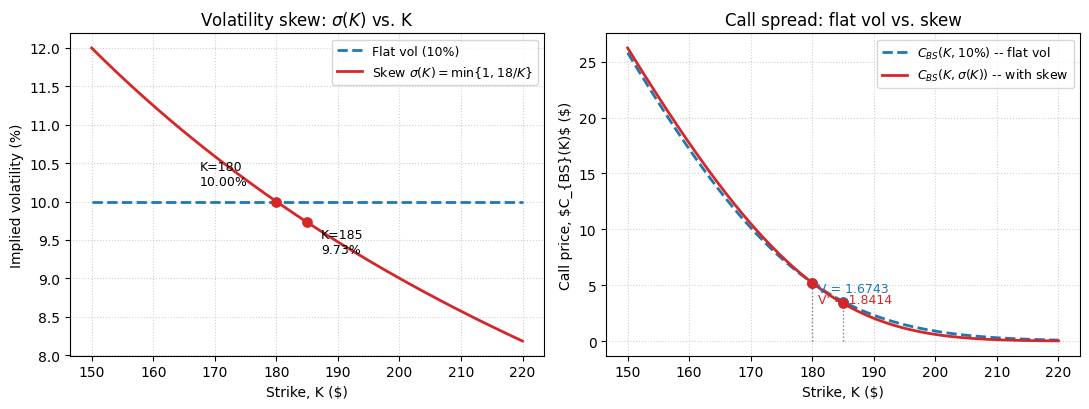

In [63]:
import matplotlib.pyplot as plt

COLOR_FLAT = "#1f77b4"   # flat-vol / no-skew series
COLOR_SKEW = "#d62728"   # skewed-vol series

K_grid = np.linspace(150, 220, 300)
sigma_flat_grid = np.full_like(K_grid, sigma)
sigma_skew_grid = np.minimum(1.0, 18.0 / K_grid)
call_flat_grid = np.array([bsm_call(S0, K, sigma, T) for K in K_grid])
call_skew_grid = np.array([bsm_call(S0, K, min(1.0, 18.0 / K), T) for K in K_grid])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.plot(K_grid, sigma_flat_grid * 100, color=COLOR_FLAT, ls="--", lw=2, label="Flat vol (10%)")
ax.plot(K_grid, sigma_skew_grid * 100, color=COLOR_SKEW, ls="-", lw=2, label=r"Skew $\sigma(K)=\min\{1,18/K\}$")
ax.scatter([K1, K2], [sigma_180 * 100, sigma_185 * 100], color=COLOR_SKEW, zorder=5, s=45)
offsets = {K1: (-55, 12), K2: (10, -22)}
for K, s in [(K1, sigma_180), (K2, sigma_185)]:
    ax.annotate(f"K={K:.0f}\n{s*100:.2f}%", (K, s * 100), textcoords="offset points",
                xytext=offsets[K], fontsize=9)
ax.set_xlabel("Strike, K ($)")
ax.set_ylabel("Implied volatility (%)")
ax.set_title("Volatility skew: $\\sigma(K)$ vs. K")
ax.grid(True, ls=":", alpha=0.6)
ax.legend(loc="upper right", fontsize=9)

ax = axes[1]
ax.plot(K_grid, call_flat_grid, color=COLOR_FLAT, ls="--", lw=2, label="$C_{BS}(K,10\\%)$ -- flat vol")
ax.plot(K_grid, call_skew_grid, color=COLOR_SKEW, ls="-", lw=2, label="$C_{BS}(K,\\sigma(K))$ -- with skew")
ax.scatter([K1, K2], [C180_flat, C185_flat], color=COLOR_FLAT, zorder=5, s=45)
ax.scatter([K1, K2], [C180_skew, C185_skew], color=COLOR_SKEW, zorder=5, s=45)
ax.vlines([K1, K2], 0, [max(C180_flat, C180_skew), max(C185_flat, C185_skew)],
          color="gray", ls=":", lw=1)
ax.annotate(f"V = {V:.4f}", (K1 + 1, (C180_flat + C185_flat) / 2), color=COLOR_FLAT, fontsize=9)
ax.annotate(f"V' = {Vp:.4f}", (K1 + 1, (C180_skew + C185_skew) / 2 - 0.9), color=COLOR_SKEW, fontsize=9)
ax.set_xlabel("Strike, K ($)")
ax.set_ylabel("Call price, $C_{BS}(K)$ ($)")
ax.set_title("Call spread: flat vol vs. skew")
ax.grid(True, ls=":", alpha=0.6)
ax.legend(loc="upper right", fontsize=9)

fig.tight_layout()
plt.show()


### A genuine 3D surface: call price as a function of strike *and* volatility

The slides' own picture of "the volatility surface" (*"The Volatility Surface"* deck) plots
implied vol against **Strike $\times$ Time-to-maturity**. We can't honestly reproduce that exact
picture here: this assignment only specifies $\sigma(K)$ at the single maturity $T=1$ year — it
gives us no term structure, and inventing one would mean plotting data the quiz never gave us.

Instead, here is a **fully grounded** 3D surface built only from quantities this assignment
*does* define: the Black-Scholes call price $C_{\text{BS}}(K,\sigma)$ swept across **both** strike
$K$ and volatility $\sigma$ (holding $S_0,r,T$ fixed at the given values). This is legitimate
because $C_{\text{BS}}(K,\sigma)$ is, by the BS formula, a pure function of the *point* $(K,\sigma)$
— no term-structure assumption is needed to plot it.

On top of the surface we trace the **two paths** Q9/Q10 actually walk:
- the **flat-vol path** (blue): $\sigma\equiv10\%$ for every $K$ — a straight line across the
  surface at constant height $\sigma=10$.
- the **market-skew path** (red): $\sigma(K)=\min\{1,18/K\}$ — a curve that dips *down* in
  $\sigma$ as $K$ increases, cutting across the surface.

$V$ and $V'$ (Q9, Q10) are exactly the vertical drops in $C$ between the $K{=}180$ and $K{=}185$
markers *along each respective path*.


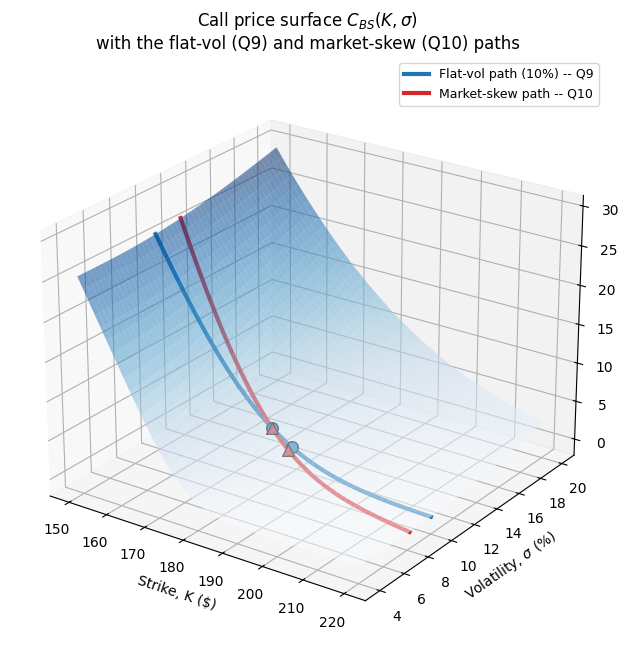

Note: C(180, flat) and C(180, skew) coincide (both blue AND red markers sit at the same
point at K=180) because sigma(180)=10% exactly -- the skew curve only pulls away from the
flat line once K exceeds 180, which is exactly why V and V' only start to differ at K=185.


In [64]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3D projection)

K_surf = np.linspace(150, 220, 50)
sigma_surf = np.linspace(0.04, 0.20, 50)
KK, SIGSIG = np.meshgrid(K_surf, sigma_surf)
CC = np.array([[bsm_call(S0, K, s, T) for K in K_surf] for s in sigma_surf])

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(KK, SIGSIG * 100, CC, cmap="Blues", alpha=0.55, linewidth=0, antialiased=True)

# flat-vol path traced on the surface
flat_path_C = np.array([bsm_call(S0, K, sigma, T) for K in K_surf])
ax.plot(K_surf, np.full_like(K_surf, sigma * 100), flat_path_C,
        color=COLOR_FLAT, lw=3, label="Flat-vol path (10%) -- Q9")

# market-skew path traced on the surface
skew_path_sigma = np.minimum(1.0, 18.0 / K_surf)
skew_path_C = np.array([bsm_call(S0, K, s, T) for K, s in zip(K_surf, skew_path_sigma)])
ax.plot(K_surf, skew_path_sigma * 100, skew_path_C,
        color=COLOR_SKEW, lw=3, label="Market-skew path -- Q10")

# the four Q9/Q10 evaluation points
ax.scatter([K1, K2], [sigma * 100, sigma * 100], [C180_flat, C185_flat],
           color=COLOR_FLAT, s=70, edgecolor="k", depthshade=False, zorder=5)
ax.scatter([K1, K2], [sigma_180 * 100, sigma_185 * 100], [C180_skew, C185_skew],
           color=COLOR_SKEW, s=70, marker="^", edgecolor="k", depthshade=False, zorder=5)

ax.set_xlabel("Strike, K ($)")
ax.set_ylabel("Volatility, $\\sigma$ (%)")
ax.set_zlabel("Call price, $C_{BS}(K,\\sigma)$ ($)")
ax.set_title("Call price surface $C_{BS}(K,\\sigma)$\nwith the flat-vol (Q9) and market-skew (Q10) paths")
ax.view_init(elev=24, azim=-55)
ax.zaxis.labelpad = 12
ax.legend(loc="upper right", fontsize=9)
fig.subplots_adjust(left=0.02, right=0.90, top=0.90, bottom=0.05)
plt.show()

print("Note: C(180, flat) and C(180, skew) coincide (both blue AND red markers sit at the same")
print("point at K=180) because sigma(180)=10% exactly -- the skew curve only pulls away from the")
print("flat line once K exceeds 180, which is exactly why V and V' only start to differ at K=185.")


# Part 3: Digital Option and Volatility Surface II (Q11–Q14)

**Slide definition** (*"Pricing Derivatives Using the Volatility Surface"*, slide *"Pricing a
Digital Option"*): a digital (cash-or-nothing) call pays $\mathbf{1}_{\{S_T\ge K\}}$, and its
price $D(K,T)$ is obtained as the strike-derivative of the *market* call price curve:
$$
D(K,T)=\lim_{\Delta K\to0}\frac{C_{\text{mkt}}(K,T)-C_{\text{mkt}}(K+\Delta K,T)}{\Delta K}
=-\frac{\partial C_{\text{mkt}}(K,T)}{\partial K}
$$
Back to 10am, March 8, 2019, constant vol $\sigma=10\%$ (until Q14).


## Question 11 — Digital call price $D(K,T)$

**Formula (flat surface, $\sigma(K,T)\equiv\sigma$):** since there is no skew term yet
(that's Q14), $C_{\text{mkt}}(K,T)=C_{\text{BS}}(K,T,\sigma)$ exactly, and differentiating the
slide eq. 9 formula in $K$ gives (using $Se^{-cT}\varphi(d_1)=Ke^{-rT}\varphi(d_2)$ and
$\partial d_1/\partial K=\partial d_2/\partial K$ so the $\varphi$-terms cancel):
$$
D(K,T) = -\frac{\partial C_{\text{BS}}}{\partial K} = e^{-rT}N(d_2)
$$
We reuse $d_2$ from Q1.

**Range check from Put-Call Parity:** payoff $\mathbf 1_{\{S_T\ge K\}}\in[0,1]$, so
$0\le D(K,T)\le e^{-rT}$ (the price of a sure \$1 at $T$). We verify our answer sits in this band.

**Comparison with Delta from Q2 — think about why they differ:** $\Delta_{\text{call}}=N(d_1)$
(Q2, with $c=0$) *looks* similar to $D(K,T)=e^{-rT}N(d_2)$, but they are **not** the same: (i) the
digital price is discounted by $e^{-rT}$, Delta is not; (ii) $N(d_2)=\mathbb Q(S_T\ge K)$ is the
exercise probability under the plain risk-neutral (money-market numéraire) measure, while
$N(d_1)=\mathbb Q^S(S_T\ge K)$ is under the **stock-numéraire measure** — a genuinely different
probability measure — so there is no reason for the two numbers to coincide.


In [65]:
Dig180_flat = digital_call(S0, K1, sigma, T)
discount_factor = math.exp(-r * T)

print(f"e^(-rT) (upper bound) = {discount_factor:.6f}")
print(f"D(180,T) = e^(-rT)*N(d2) = {Dig180_flat:.6f}  ->  rounded: {round4(Dig180_flat)}")

assert 0 <= Dig180_flat <= discount_factor, "Digital call price must lie in [0, e^(-rT)] by put-call-parity bounds"
print("Range check OK: 0 <= D(K,T) <= e^(-rT).")
print(f"For comparison, Delta from Q2 (N(d1)) = {round4(Delta0)}  (different measure/discounting -- see markdown)")

answers['Q11_digital_call'] = round4(Dig180_flat)


e^(-rT) (upper bound) = 0.970446
D(180,T) = e^(-rT)*N(d2) = 0.384807  ->  rounded: 0.3848
Range check OK: 0 <= D(K,T) <= e^(-rT).
For comparison, Delta from Q2 (N(d1)) = 0.4355  (different measure/discounting -- see markdown)


## Question 12 — Delta-hedging the digital option

**Setup:** sell $D(K,T)$ at the Q11 price and Delta-hedge it, so — mirroring Q6's $B_0=V_0-\delta_0S_0$
sign convention — hold $+\delta_{\text{Dig}}$ shares, where $\delta_{\text{Dig}}$ is the digital
option's own Delta:
$$
\delta_{\text{Dig}}=\frac{\partial D(K,T)}{\partial S}
=e^{-rT}\varphi(d_2)\frac{\partial d_2}{\partial S}
=\frac{e^{-rT}\varphi(d_2)}{S\sigma\sqrt{T}}
$$
using $\partial d_2/\partial S=\partial d_1/\partial S=1/(S\sigma\sqrt T)$ (since $d_1,d_2$ differ
only by the $S$-independent constant $\sigma\sqrt T$).

**Comparison with Gamma from Q3 — a structural link, via the slides' Breeden-Litzenberger
result** (*"What the Volatility Surface Tells Us"*, eq. 6): $f_T(K)=e^{rT}\dfrac{\partial^2
C}{\partial K^2}$ is the risk-neutral density of $S_T$. Compare
$\delta_{\text{Dig}}=\dfrac{e^{-rT}\varphi(d_2)}{S\sigma\sqrt T}$ to
$\Gamma_{\text{call}}=\dfrac{\varphi(d_1)}{S\sigma\sqrt T}$ (Q3, $c=0$): both share the same
"density $/(S\sigma\sqrt T)$" shape, differing only by the discount factor and by $d_2$ vs.
$d_1$ — because a digital option is, in the limit, a $K$-derivative of a call (Breeden-
Litzenberger), while Gamma is an $S$-derivative of Delta; both are, structurally, densities of the
same underlying distribution, just taken with respect to different variables.


In [66]:
DigDelta180 = digital_delta(S0, K1, sigma, T)
print(f"delta_Dig = e^(-rT)*phi(d2)/(S0*sigma*sqrt(T)) = {DigDelta180:.6f}  ->  rounded: {round4(DigDelta180)}")
print("-> shares to BUY to delta-hedge the short digital call position (positive => buy).")

print(f"\nFor comparison, Gamma of the vanilla call (Q3) = {round4(Gamma0)}")
print("Same functional shape (density / (S*sigma*sqrt(T))), differing by discount factor and d2 vs d1 -- see markdown.")

assert DigDelta180 > 0
print("\nSign check OK: positive, i.e. we buy shares to hedge the short digital call, same convention as Q6/Q7.")

answers['Q12_digital_delta_shares'] = round4(DigDelta180)


delta_Dig = e^(-rT)*phi(d2)/(S0*sigma*sqrt(T)) = 0.021873  ->  rounded: 0.0219
-> shares to BUY to delta-hedge the short digital call position (positive => buy).

For comparison, Gamma of the vanilla call (Q3) = 0.023
Same functional shape (density / (S*sigma*sqrt(T))), differing by discount factor and d2 vs d1 -- see markdown.

Sign check OK: positive, i.e. we buy shares to hedge the short digital call, same convention as Q6/Q7.


## Question 13 — Digital call spread, flat volatility

**Formula:** buy $D(180,T)$, sell $D(185,T)$, both at $\sigma(K,T)=10\%$:
$$
W = D(180,T) - D(185,T)
$$

**Logic double-check:** $D(K,T)=e^{-rT}N(d_2(K))$ is *decreasing* in $K$ (harder to finish above
a higher strike), so — exactly like Q9's vanilla spread — we expect $W>0$.


In [67]:
Dig185_flat = digital_call(S0, K2, sigma, T)
W = Dig180_flat - Dig185_flat

print(f"D(180,T), sigma=10% = {Dig180_flat:.6f}  (= Q11 answer)")
print(f"D(185,T), sigma=10% = {Dig185_flat:.6f}  ->  rounded: {round4(Dig185_flat)}")
print(f"W = {W:.6f}  ->  rounded: {round4(W)}")

assert Dig180_flat > Dig185_flat
assert W > 0
print("Sign check OK: W > 0, as expected (digital call price decreasing in strike).")

answers['Q13_W_flat'] = round4(W)


D(180,T), sigma=10% = 0.384807  (= Q11 answer)
D(185,T), sigma=10% = 0.287118  ->  rounded: 0.2871
W = 0.097689  ->  rounded: 0.0977
Sign check OK: W > 0, as expected (digital call price decreasing in strike).


## Question 14 — Digital call spread, with volatility skew (chain rule)

**Slide formula used verbatim** (*"Pricing a Digital Option"* — chain rule slide, eq. 7):
market prices satisfy $C_{\text{mkt}}(K,T)=C_{\text{BS}}(K,T,\sigma(K,T))$, so
$$
D(K,T)=-\frac{dC_{\text{BS}}(K,T,\sigma(K,T))}{dK}
=-\frac{\partial C_{\text{BS}}}{\partial K}-\frac{\partial C_{\text{BS}}}{\partial\sigma}\cdot\frac{\partial\sigma(K)}{\partial K}
=-\frac{\partial C_{\text{BS}}}{\partial K}-\text{vega}\times\text{skew}
$$
— this is *exactly* the chain-rule formula the quiz gives for Q14, and matches the slide's own
worked Gatheral example (*"An Example from Gatheral's 'The Volatility Surface'"*), which computes
a digital price as *"the flat-vol level $\pm$ a Vega$\times$skew correction"*.

Here (evaluated at each strike's own skew-implied vol $\sigma(K)$):
$$
\frac{\partial C_{\text{BS}}}{\partial K}=-e^{-rT}N(d_2),\qquad
\text{vega}=S_0\varphi(d_1)\sqrt{T},\qquad
\text{skew}=\frac{\partial \sigma(K)}{\partial K}=\frac{d}{dK}\Big(\frac{18}{K}\Big)=-\frac{18}{K^2}
\quad(K>18)
$$
so
$$
D(K,T)=\underbrace{e^{-rT}N(d_2)}_{\text{"level" term}}\;+\;\underbrace{\text{vega}\cdot\frac{18}{K^2}}_{\text{"skew" correction}}
$$

**Sanity check on the formula itself:** if the skew slope were $0$, the correction vanishes and
this collapses back to exactly Q11's formula — verified numerically below.

**Logic double-check on direction:** $\text{skew}=-18/K^2<0$ everywhere (downward-sloping) and
$\text{vega}>0$, so the correction $\text{vega}\cdot18/K^2$ is **strictly positive** — a
downward-sloping skew always makes a digital call **more expensive** than the flat "level" term
alone suggests, *even at $K=180$* where $\sigma(180)=10\%$ matches the flat-vol case exactly —
because the digital price cares about the *local slope* of the skew, not just its level at one
point.

**Compare $W'-W$ (skew) with $V'-V$ (Q10, vanilla):** the vanilla spread's skew-sensitivity comes
from the *difference in vol level* between strikes ($\sigma(180)-\sigma(185)$), which does **not**
cancel when we difference the two legs. The digital spread's sensitivity instead comes from the
*local slope* $-18/K^2$, which is *similar in magnitude* at $K=180$ and $K=185$ — so much of the
slope-driven correction **cancels** in the long-short difference $W'-W$, even though the raw skew
input is identical for both spreads.


In [68]:
def dsigma_dK(K):
    """Derivative of sigma(K) = min(1, 18/K) w.r.t. K, in the region 18/K < 1 (K > 18)."""
    assert 18.0 / K < 1, "K is outside the region where sigma(K) = 18/K"
    return -18.0 / K**2

def partial_dC_dK(S, K, sigma, tau, r=r, c=c):
    """Partial derivative of C_BS w.r.t. K, holding sigma fixed: dC/dK = -e^(-rT) N(d2)."""
    _, d2 = d1d2(S, K, sigma, tau, r, c)
    return -math.exp(-r * tau) * norm.cdf(d2)

def digital_with_skew(S, K, r, T):
    """D(K,T) = -dC/dK - vega*skew, i.e. slide eq. 7."""
    sig = min(1, 18.0 / K)
    dC_dK = partial_dC_dK(S, K, sig, T, r)
    veg = bsm_vega(S, K, sig, T, r)
    skew = dsigma_dK(K)
    return -(dC_dK + veg * skew)

# sanity check: forcing the skew-slope to zero must reproduce the flat-vol Q11 answer exactly
flat_reproduction = -partial_dC_dK(S0, K1, sigma, T)
assert math.isclose(flat_reproduction, Dig180_flat, rel_tol=1e-12)
print(f"Sanity check OK: with zero skew-slope, eq. 7 reproduces Q11's flat-vol digital price ({flat_reproduction:.6f}).")

Dig180_skew = digital_with_skew(S0, K1, r, T)
Dig185_skew = digital_with_skew(S0, K2, r, T)
Wp = Dig180_skew - Dig185_skew

print(f"\nsigma(180) = {sigma_180:.6f}, skew|_180 = dsigma/dK = {dsigma_dK(K1):.6e}")
print(f"sigma(185) = {sigma_185:.6f}, skew|_185 = dsigma/dK = {dsigma_dK(K2):.6e}")
print(f"\nD(180,T; skew) = {Dig180_skew:.6f}  ->  rounded: {round4(Dig180_skew)}"
      f"   (level term e^-rT N(d2)={Dig180_flat:.6f} + vega*skew correction={Dig180_skew-Dig180_flat:.6f})")
print(f"D(185,T; skew) = {Dig185_skew:.6f}  ->  rounded: {round4(Dig185_skew)}")
print(f"W' = {Wp:.6f}  ->  rounded: {round4(Wp)}")

assert Dig180_skew > Dig180_flat, "Downward skew slope should make the digital MORE expensive than the flat-level term, even at K=180"
print("\nSign check OK: D(180,T;skew) > D(180,T;flat), confirming the positive vega*skew argument above.")

print(f"\nW' - W = {Wp - W:.6f}   (absolute skew impact on the DIGITAL spread)")
print(f"V' - V = {Vp - V:.6f}   (absolute skew impact on the VANILLA spread, from Q10)")
print(f"Relative impact: (W'-W)/W = {(Wp-W)/W:.2%}   vs   (V'-V)/V = {(Vp-V)/V:.2%}")
print("-> the vanilla spread's absolute dollar sensitivity to this skew is larger, exactly as the")
print("   'level difference doesn't cancel, but slope similarity mostly does' argument above predicts.")

answers['Q14_Wprime_skew'] = round4(Wp)


Sanity check OK: with zero skew-slope, eq. 7 reproduces Q11's flat-vol digital price (0.384807).

sigma(180) = 0.100000, skew|_180 = dsigma/dK = -5.555556e-04
sigma(185) = 0.097297, skew|_185 = dsigma/dK = -5.259313e-04

D(180,T; skew) = 0.422213  ->  rounded: 0.4222   (level term e^-rT N(d2)=0.384807 + vega*skew correction=0.037406)
D(185,T; skew) = 0.315463  ->  rounded: 0.3155
W' = 0.106749  ->  rounded: 0.1067

Sign check OK: D(180,T;skew) > D(180,T;flat), confirming the positive vega*skew argument above.

W' - W = 0.009060   (absolute skew impact on the DIGITAL spread)
V' - V = 0.167100   (absolute skew impact on the VANILLA spread, from Q10)
Relative impact: (W'-W)/W = 9.27%   vs   (V'-V)/V = 9.98%
-> the vanilla spread's absolute dollar sensitivity to this skew is larger, exactly as the
   'level difference doesn't cancel, but slope similarity mostly does' argument above predicts.


### Visualizing the digital price curve, the skew correction, and Breeden-Litzenberger

Two more plots:

- **Left:** $D(K,T)$ across strikes, flat vol vs. skew (mirrors the call-price plot above, but
  now for the digital). Notice the skew curve sits *above* the flat curve **everywhere** near
  $K=180$–$185$ (not just where $\sigma(K)$ dips below $10\%$) — visual confirmation of the
  Q14 finding that the correction depends on the *slope* $\partial\sigma/\partial K$, not the
  *level* of $\sigma(K)$ alone.
- **Right:** a direct check of the slide's defining identity
  $D(K,T)=-\partial C_{\text{mkt}}/\partial K$ (Breeden-Litzenberger, also referenced in Q12): we
  overlay our closed-form $D(K,T)=e^{-rT}N(d_2)$ against a **numerical finite-difference
  derivative** of the flat-vol call curve from the Part 2 plot,
  $-\big(C(K+\epsilon)-C(K-\epsilon)\big)/(2\epsilon)$. The two should sit on top of each other —
  if they don't, something upstream is wrong.


Max abs difference between analytic D(K,T) and finite-difference -dC/dK: 0.000000
Cross-check OK: analytic digital price matches the numerical strike-derivative of the call curve.


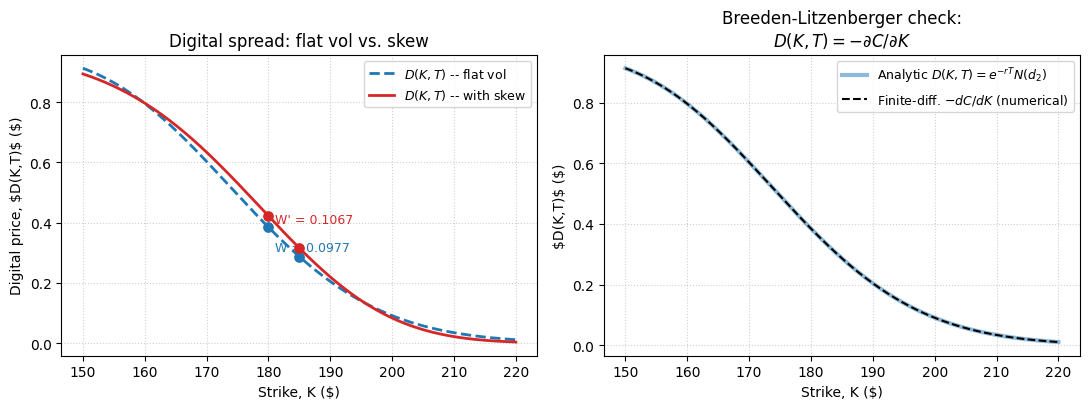

In [69]:
digital_flat_grid = np.array([digital_call(S0, K, sigma, T) for K in K_grid])
digital_skew_grid = np.array([digital_with_skew(S0, K, r, T) for K in K_grid])

# independent numerical cross-check of D(K,T) = -dC/dK via central finite differences
eps = 0.01
finite_diff_D = -(np.array([bsm_call(S0, K + eps, sigma, T) for K in K_grid])
                   - np.array([bsm_call(S0, K - eps, sigma, T) for K in K_grid])) / (2 * eps)
max_abs_diff = np.max(np.abs(finite_diff_D - digital_flat_grid))
print(f"Max abs difference between analytic D(K,T) and finite-difference -dC/dK: {max_abs_diff:.6f}")
assert max_abs_diff < 1e-3, "Finite-difference check of D(K,T) = -dC/dK failed"
print("Cross-check OK: analytic digital price matches the numerical strike-derivative of the call curve.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.plot(K_grid, digital_flat_grid, color=COLOR_FLAT, ls="--", lw=2, label="$D(K,T)$ -- flat vol")
ax.plot(K_grid, digital_skew_grid, color=COLOR_SKEW, ls="-", lw=2, label="$D(K,T)$ -- with skew")
ax.scatter([K1, K2], [Dig180_flat, Dig185_flat], color=COLOR_FLAT, zorder=5, s=45)
ax.scatter([K1, K2], [Dig180_skew, Dig185_skew], color=COLOR_SKEW, zorder=5, s=45)
ax.annotate(f"W = {W:.4f}", (K1 + 1, (Dig180_flat + Dig185_flat) / 2 - 0.03), color=COLOR_FLAT, fontsize=9)
ax.annotate(f"W' = {Wp:.4f}", (K1 + 1, (Dig180_skew + Dig185_skew) / 2 + 0.03), color=COLOR_SKEW, fontsize=9)
ax.set_xlabel("Strike, K ($)")
ax.set_ylabel("Digital price, $D(K,T)$ ($)")
ax.set_title("Digital spread: flat vol vs. skew")
ax.grid(True, ls=":", alpha=0.6)
ax.legend(loc="upper right", fontsize=9)

ax = axes[1]
ax.plot(K_grid, digital_flat_grid, color=COLOR_FLAT, lw=3, alpha=0.5, label="Analytic $D(K,T)=e^{-rT}N(d_2)$")
ax.plot(K_grid, finite_diff_D, color="black", ls="--", lw=1.5, label="Finite-diff. $-dC/dK$ (numerical)")
ax.set_xlabel("Strike, K ($)")
ax.set_ylabel("$D(K,T)$ ($)")
ax.set_title("Breeden-Litzenberger check:\n$D(K,T)=-\\partial C/\\partial K$")
ax.grid(True, ls=":", alpha=0.6)
ax.legend(loc="upper right", fontsize=9)

fig.tight_layout()
plt.show()


### A genuine 3D surface for the digital price — and where the chain-rule correction lives

We build the same kind of surface as in Part 2, but now for the **pointwise** digital formula
$D(K,\sigma)=e^{-rT}N(d_2(K,\sigma))$ swept across $(K,\sigma)$.

**This surface needs one careful caveat, and it's the whole point of Q14.** The flat-vol path
($\sigma\equiv10\%$) sits *exactly* on this surface, because with no skew there is no
$\text{vega}\times\text{skew}$ correction — $D(K,T)$ really is just the pointwise formula. But
the **skew-adjusted** prices from Q14, $D(180,T;\text{skew})=0.4222$ and
$D(185,T;\text{skew})=0.3155$, are **not** points on this pointwise surface: Q14's formula is
$$
D(K,T)=\underbrace{e^{-rT}N(d_2(K,\sigma(K)))}_{\text{sits ON the surface, at }(K,\sigma(K))}
\;+\;\underbrace{\text{vega}(K,\sigma(K))\cdot\frac{18}{K^2}}_{\text{lifts the point OFF the surface}}
$$
So below we plot the skew-adjusted points *floating above* the surface, connected by a dashed
"lift" stem down to where the naive pointwise value would be — the length of that stem **is** the
$\text{vega}\times\text{skew}$ correction term from Q14's markdown. This is the clearest way to
*see* why "the level of $\sigma$ at a strike" and "the correct digital price at that strike" are
two different things once the surface isn't flat.


Naive surface value at (K=180, sigma(180)) = 0.384807  (== Q11's flat answer, since sigma(180)=10%)
Naive surface value at (K=185, sigma(185)) = 0.283055
'Lift' off the surface at K=180 (the vega*skew term) = 0.037406
'Lift' off the surface at K=185 (the vega*skew term) = 0.032408


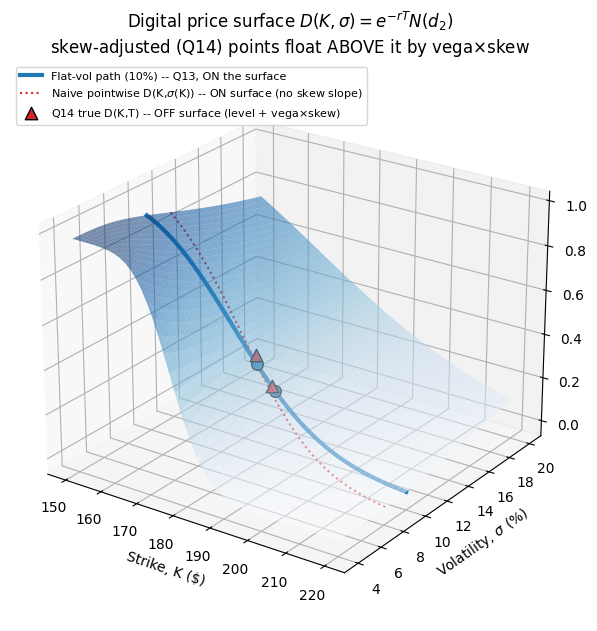

In [70]:
DD = np.array([[digital_call(S0, K, s, T) for K in K_surf] for s in sigma_surf])

# the "naive" pointwise value at each skew strike's own implied vol -- i.e. the level term,
# with NO vega*skew correction. This is exactly a point ON the DD surface.
naive_at_180 = digital_call(S0, K1, sigma_180, T)
naive_at_185 = digital_call(S0, K2, sigma_185, T)
lift_180 = Dig180_skew - naive_at_180
lift_185 = Dig185_skew - naive_at_185
print(f"Naive surface value at (K=180, sigma(180)) = {naive_at_180:.6f}  (== Q11's flat answer, since sigma(180)=10%)")
print(f"Naive surface value at (K=185, sigma(185)) = {naive_at_185:.6f}")
print(f"'Lift' off the surface at K=180 (the vega*skew term) = {lift_180:.6f}")
print(f"'Lift' off the surface at K=185 (the vega*skew term) = {lift_185:.6f}")
assert lift_180 > 0 and lift_185 > 0, "Both lifts should be positive: downward skew always lifts the digital price above the naive surface"

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(KK, SIGSIG * 100, DD, cmap="Blues", alpha=0.55, linewidth=0, antialiased=True)

flat_path_D = np.array([digital_call(S0, K, sigma, T) for K in K_surf])
ax.plot(K_surf, np.full_like(K_surf, sigma * 100), flat_path_D,
        color=COLOR_FLAT, lw=3, label="Flat-vol path (10%) -- Q13, ON the surface")

# naive (uncorrected) skew path -- sits ON the surface
naive_skew_path_D = np.array([digital_call(S0, K, s, T) for K, s in zip(K_surf, skew_path_sigma)])
ax.plot(K_surf, skew_path_sigma * 100, naive_skew_path_D,
        color=COLOR_SKEW, lw=1.5, ls=":", label="Naive pointwise D(K,$\\sigma$(K)) -- ON surface (no skew slope)")

# Q14's true skew-adjusted points -- float ABOVE the surface, with a "lift" stem down to it
ax.scatter([K1, K2], [sigma * 100, sigma * 100], [Dig180_flat, Dig185_flat],
           color=COLOR_FLAT, s=70, edgecolor="k", depthshade=False, zorder=5)
ax.scatter([K1, K2], [sigma_180 * 100, sigma_185 * 100], [Dig180_skew, Dig185_skew],
           color=COLOR_SKEW, s=80, marker="^", edgecolor="k", depthshade=False, zorder=6,
           label="Q14 true D(K,T) -- OFF surface (level + vega$\\times$skew)")
for K, s, z_low, z_high in [(K1, sigma_180, naive_at_180, Dig180_skew), (K2, sigma_185, naive_at_185, Dig185_skew)]:
    ax.plot([K, K], [s * 100, s * 100], [z_low, z_high], color="gray", ls="--", lw=1.5)

ax.set_xlabel("Strike, K ($)")
ax.set_ylabel("Volatility, $\\sigma$ (%)")
ax.set_zlabel("Digital price, $D(K,\\sigma)$ ($)")
ax.set_title("Digital price surface $D(K,\\sigma)=e^{-rT}N(d_2)$\nskew-adjusted (Q14) points float ABOVE it by vega$\\times$skew")
ax.view_init(elev=24, azim=-55)
ax.zaxis.labelpad = 12
ax.legend(loc="upper left", fontsize=8)
fig.subplots_adjust(left=0.02, right=0.90, top=0.85, bottom=0.05)
plt.show()


# Summary of all 14 answers

All figures rounded to 4 decimals per the assignment's round-half-up convention. The "Slide
formula" column is the exact lecture-slide equation each answer implements (all with $c=0$,
the no-dividend case given in this problem).


In [71]:
summary = pd.DataFrame([
    ("Q1",  "Call price C0",                                  answers['Q1_call_price'],              "C0 = S0*e^-cT*N(d1) - K*e^-rT*N(d2)  (eq. 9)"),
    ("Q2",  "Delta",                                           answers['Q2_delta'],                   "delta = e^-cT * N(d1)"),
    ("Q3",  "Gamma",                                           answers['Q3_gamma'],                   "gamma = e^-cT * phi(d1)/(sigma*S*sqrt(T))"),
    ("Q4",  "Vega",                                            answers['Q4_vega'],                    "vega = e^-cT * S*sqrt(T)*phi(d1)"),
    ("Q5",  "Theta (per year)",                                answers['Q5_theta'],                   "theta = -e^-cT*S*phi(d1)*sigma/(2 sqrt T) + c*e^-cT*S*N(d1) - rKe^-rT N(d2)"),
    ("Q6",  "Net cash flow at inception",                      answers['Q6_net_cashflow'],            "B0 = V0 - delta0*S0  = -K e^-rT N(d2)"),
    ("Q7",  "Additional shares to buy (re-hedge)",             answers['Q7_rehedge_shares'],          "delta1 - delta0"),
    ("Q8",  "Change in portfolio value (1 month)",             answers['Q8_portfolio_change'],        "V1 - C1, V1 via eq. 11 recursion"),
    ("Q9",  "Call spread value V (flat vol)",                  answers['Q9_V_flat'],                  "C_BS(180,sigma) - C_BS(185,sigma)"),
    ("Q10", "Call spread value V' (with skew)",                answers['Q10_Vprime_skew'],            "C_BS(180,sigma(180)) - C_BS(185,sigma(185))"),
    ("Q11", "Digital call price D(K,T)",                       answers['Q11_digital_call'],           "D(K,T) = -dC_BS/dK = e^-rT N(d2)"),
    ("Q12", "Digital delta-hedge shares",                      answers['Q12_digital_delta_shares'],   "d D(K,T)/dS = e^-rT phi(d2)/(S sigma sqrt T)"),
    ("Q13", "Digital call spread value W (flat vol)",          answers['Q13_W_flat'],                 "D(180,T) - D(185,T)"),
    ("Q14", "Digital call spread value W' (with skew)",        answers['Q14_Wprime_skew'],            "D(K,T) = -dC_BS/dK - vega*skew  (eq. 7)"),
], columns=["Question", "Quantity", "Answer", "Slide formula implemented"])

summary


,Question,Quantity,Answer,Slide formula implemented
0,Q1,Call price C0,5.2122,C0 = S0*e^-cT*N(d1) - K*e^-rT*N(d2) (eq. 9)
1,Q2,Delta,0.4355,delta = e^-cT * N(d1)
2,Q3,Gamma,0.0230,gamma = e^-cT * phi(d1)/(sigma*S*sqrt(T))
3,Q4,Vega,67.3299,vega = e^-cT * S*sqrt(T)*phi(d1)
4,Q5,Theta (per year),-5.4445,theta = -e^-cT*S*phi(d1)*sigma/(2 sqrt T) + c*...
5,Q6,Net cash flow at inception,-69.2653,B0 = V0 - delta0*S0 = -K e^-rT N(d2)
6,Q7,Additional shares to buy (re-hedge),0.2001,delta1 - delta0
7,Q8,Change in portfolio value (1 month),-0.5836,"V1 - C1, V1 via eq. 11 recursion"
8,Q9,Call spread value V (flat vol),1.6743,"C_BS(180,sigma) - C_BS(185,sigma)"
9,Q10,Call spread value V' (with skew),1.8414,"C_BS(180,sigma(180)) - C_BS(185,sigma(185))"
